In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml


harvey = pd.read_csv("/home/bri/pymol/EDA/static/harvey_outputs/scores_df_extended_with_chai.csv")
YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)


print(f"harvey:\n{harvey['binder'].value_counts()}")


harvey.describe()

harvey:
binder
1.0    30
0.0     7
Name: count, dtype: int64


,binder,EC50[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
count,37.000000,1.000000e+00,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,0.810811,2.100000e-07,12.671702,75.893452,358.400811,11.768108,11.632929,70.467044,0.354285,0.279268,...,2.198166,0.874488,0.703416,0.549149,0.440789,0.539300,0.820484,0.835068,0.411420,0.563731
std,0.397061,NaN,1.482149,2.206551,178.897526,5.510794,3.678214,7.425059,0.200527,0.124425,...,0.683660,0.041956,0.078312,0.095432,0.143061,0.065584,0.028766,0.023326,0.149951,0.097388
min,0.000000,2.100000e-07,10.399938,71.692176,77.770000,2.870000,5.747656,59.309462,0.000000,0.091900,...,0.649316,0.782540,0.557721,0.178800,0.130400,0.411100,0.744111,0.776139,0.118825,0.320223
25%,1.000000,2.100000e-07,11.603302,74.520081,206.490000,7.260000,9.354444,64.591960,0.181534,0.180900,...,1.874488,0.842142,0.650788,0.516000,0.317900,0.505600,0.799096,0.822275,0.304552,0.491697
50%,1.000000,2.100000e-07,12.361698,76.021409,311.900000,10.870000,11.178431,69.363549,0.324790,0.259500,...,2.087020,0.880534,0.715264,0.552700,0.463000,0.543200,0.829755,0.835848,0.413043,0.571211
75%,1.000000,2.100000e-07,13.847110,77.945758,489.560000,15.400000,13.687963,76.922909,0.527363,0.355900,...,2.590167,0.906292,0.756813,0.617100,0.522100,0.590700,0.841339,0.845774,0.480093,0.615010
max,1.000000,2.100000e-07,16.662872,79.729492,717.080000,24.690000,21.531707,84.516848,0.686851,0.538000,...,4.002924,0.953019,0.871298,0.669800,0.794900,0.684200,0.866754,0.899859,0.698466,0.759819


In [5]:
cols_to_drop=(['af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif']) #, 'af3_pdockq', 'cf_pdockq', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'boltz_free_pdockq', 'boltz_template_pdockq', 'chai_constrained_per_chain_ptm', 'chai_constrained_interface_iptm', 'chai_unconstrained_interface_iptm', 'chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_unconstrained_per_chain_ptm'])  #  

scores_df = harvey.drop(columns=cols_to_drop)

# vllt drop 'KD[M]', 'EC50[M]' too?
#scores_df.head()

### data transformation

In [6]:
exclude_cols = ['KD[M]', 'EC50[M]']  # columns to exclude
numeric_cols = scores_df.select_dtypes(include=['number']).columns.tolist()

# Remove excluded columns from numeric_cols
for col in exclude_cols:
    if col in numeric_cols:
        numeric_cols.remove(col)
    

# Remove binder
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

numeric_cols
len(numeric_cols)  

80

In [8]:
# Group metrics by model (?)

models = ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained', 'boltz_free', 'boltz_template']
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

metric_families = {
    "plddt": [
        "af3_plddt",
        "cf_plddt",
        "esmfold_plddt",
        "boltz_free_plddt",
        "boltz_template_plddt",
    ],

    "ptm": [
        "af3_ptm",
        "cf_ptm",
        "esmfold_ptm",
        "chai_unconstrained_ptm",
        "chai_constrained_ptm",
        "boltz_free_ptm",
        "boltz_template_ptm",
    ],

    "iptm": [
        "af3_iptm",
        "cf_iptm",
        "chai_unconstrained_iptm",
        "chai_constrained_iptm",
        "boltz_free_iptm",
        "boltz_template_iptm",
    ],

    "pdockq2": [
        "af3_pdockq2",
        "cf_pdockq2",
        "chai_unconstrained_pdockq2",
        "chai_constrained_pdockq2",
        "boltz_free_pdockq2",
        "boltz_template_pdockq2",
    ],
}


In [18]:

# Create the 3-group logic to be able to distuinguish between easy and hard negatives
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original': # binder = 0
        return 'Non-Binder'
    else: # binder = 0 and type = target_shuffle
        return 'Target Shuffle'

scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

# Map the colors explicitly to the groups
colors_map = {
    'Binder': '#2ecc71',      # Green
    'Non-Binder': "#67e7dd",  # Aquamarine
    'Target Shuffle': "#273397",       # Blue
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397",
    'harvey': "#971f91"
}

In [16]:
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,binder_type
0,harvey,original,1.0,NaN,NaN,AT118i4h32_AGTR1,11.528240,78.049861,241.77,7.91,...,0.953019,0.871298,0.5023,0.5615,0.6842,0.796724,0.899859,0.419045,0.759819,Binder
1,harvey,original,1.0,NaN,NaN,AT201_AGTR1,12.212700,76.021409,108.25,7.19,...,0.910365,0.755096,0.4618,0.3734,0.5413,0.781721,0.829062,0.118825,0.567248,Binder
2,harvey,original,1.0,NaN,NaN,AT202_AGTR1,13.119915,76.458147,299.89,11.87,...,0.822987,0.587241,0.6138,0.2044,0.4111,0.783286,0.839246,0.179008,0.542771,Binder
3,harvey,original,1.0,NaN,NaN,AT203_AGTR1,11.603302,78.053494,77.77,2.87,...,0.910428,0.795326,0.6598,0.6871,0.5950,0.804622,0.812353,0.337474,0.616371,Binder
4,harvey,original,1.0,NaN,NaN,AT204_AGTR1,16.662872,71.692176,456.19,24.69,...,0.815329,0.557721,0.5336,0.2333,0.4120,0.799096,0.822275,0.142731,0.556965,Binder


In [12]:
# read metric_directions.yaml (directionality should be +1 for metrics where higher is better, -1 for metrics where lower is better, applied after scaling)

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

Loaded 58 metric directions from YAML.


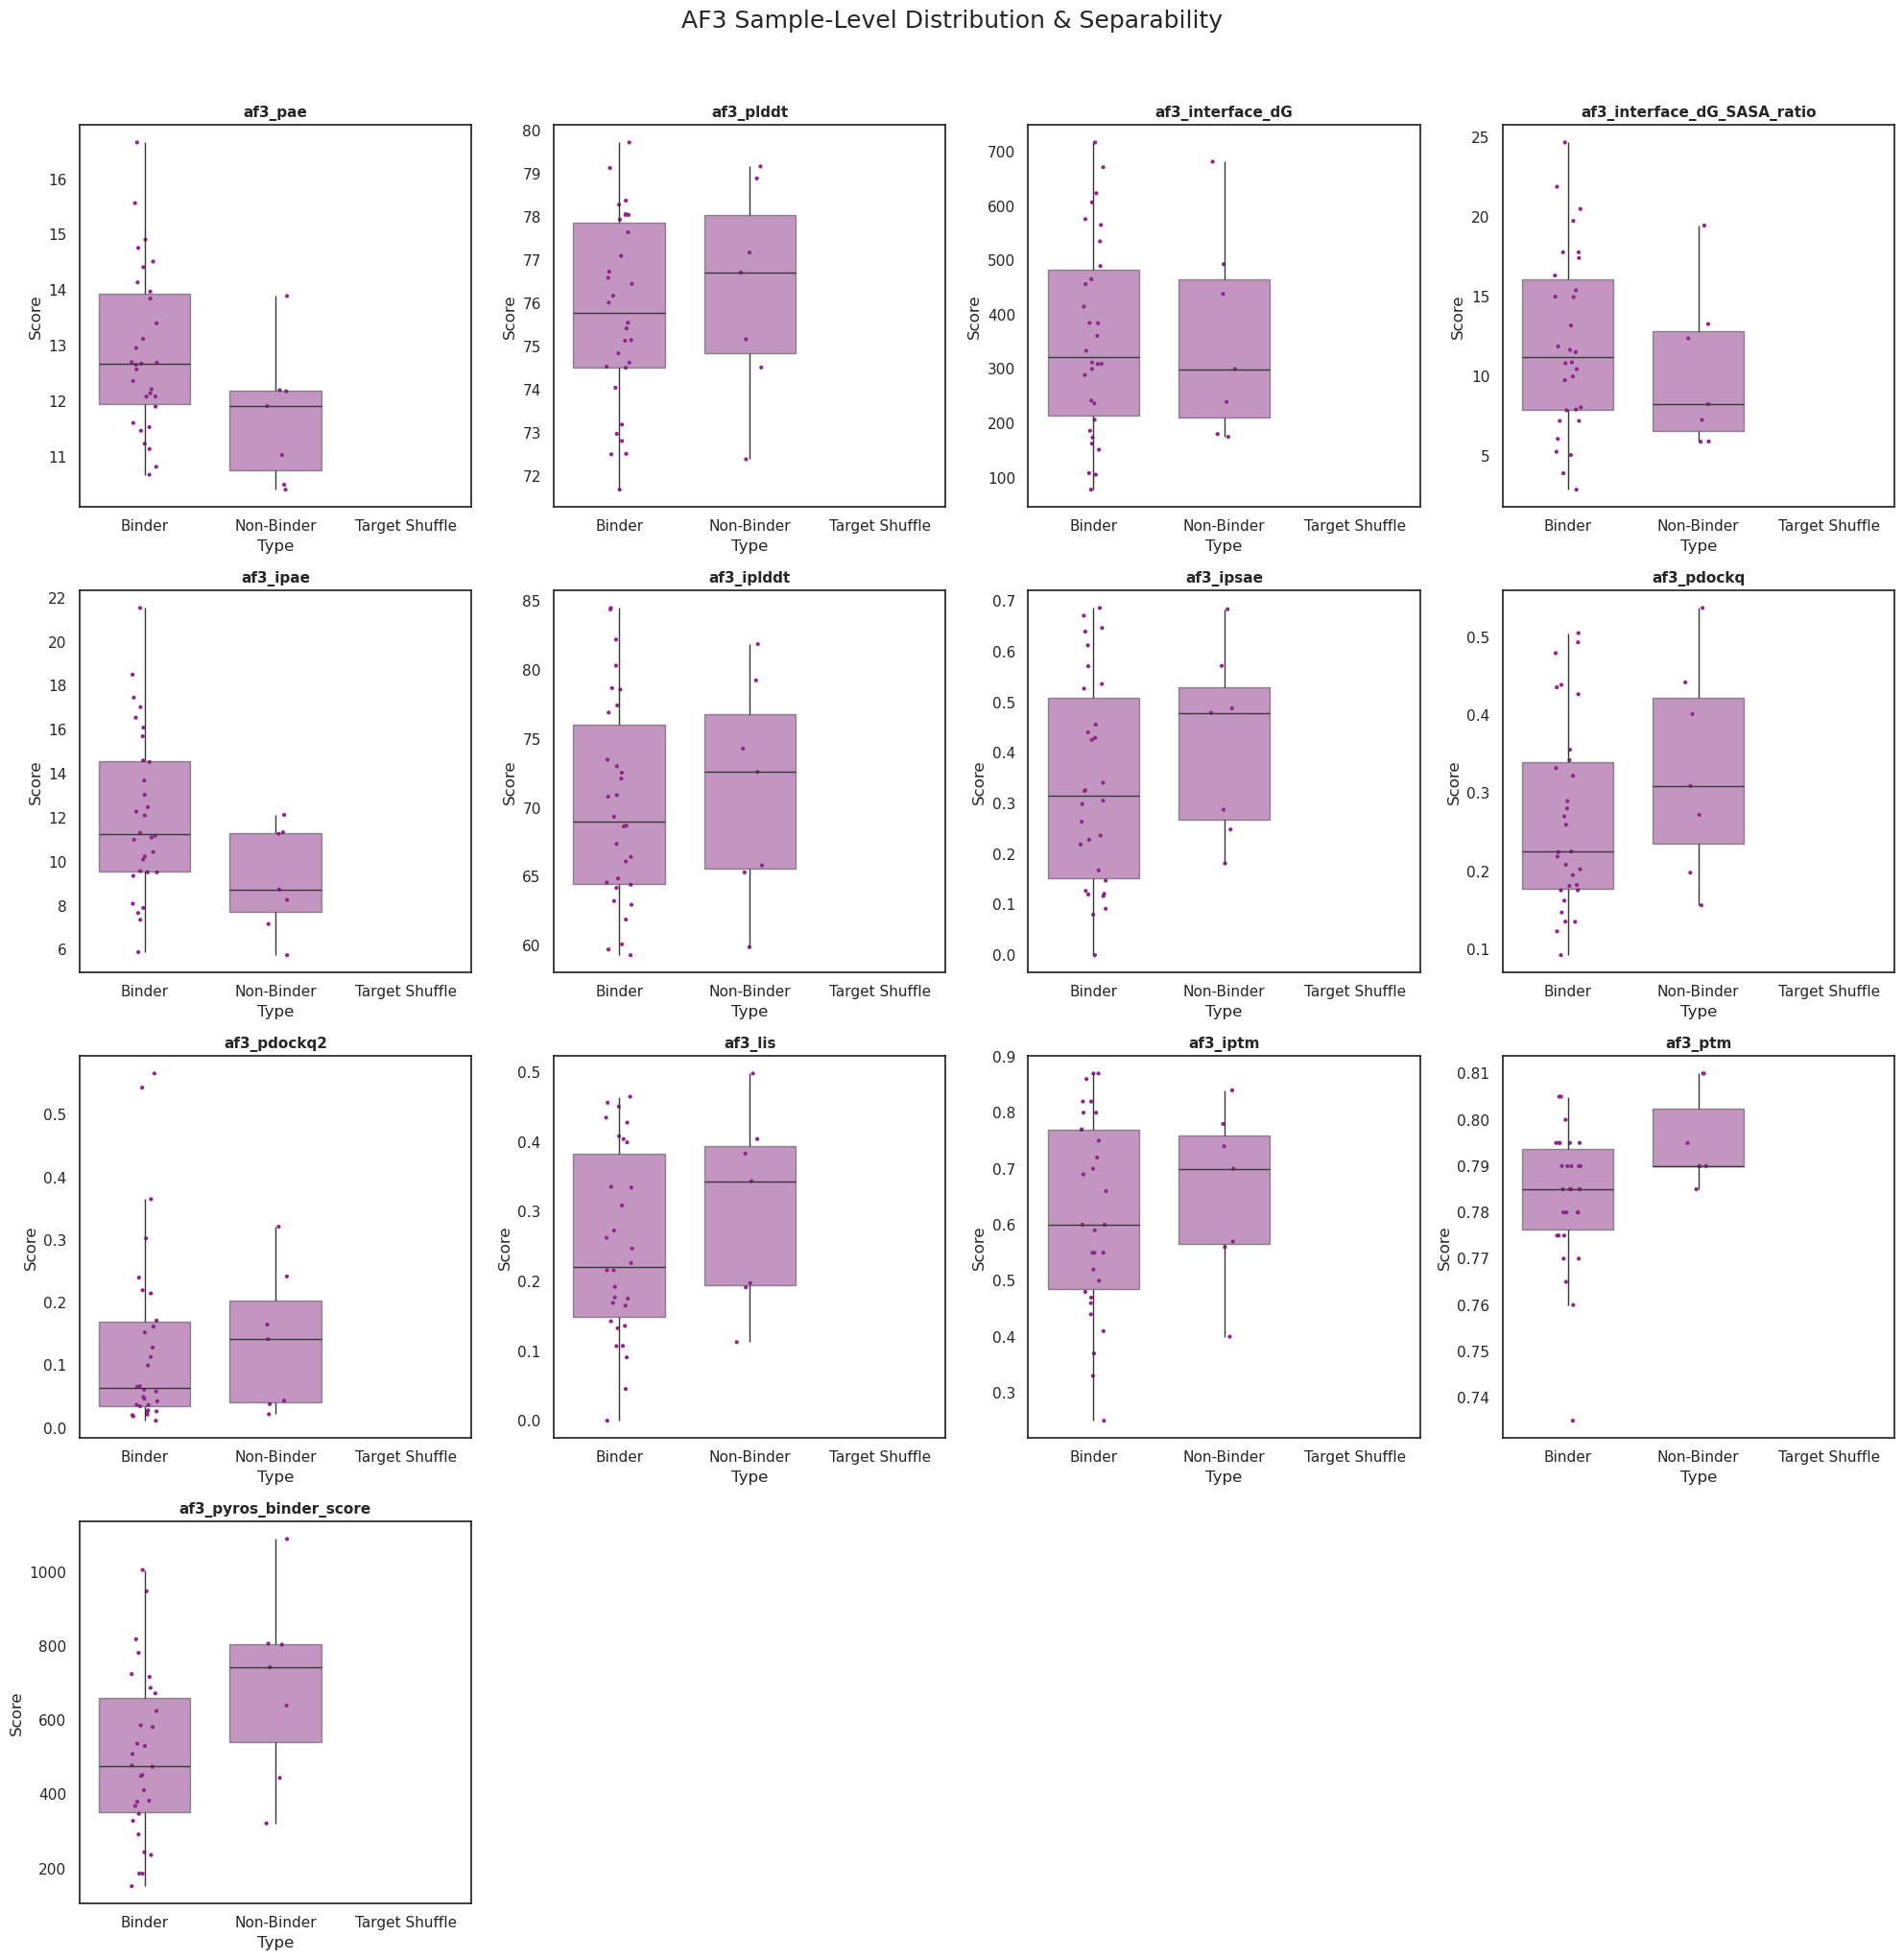

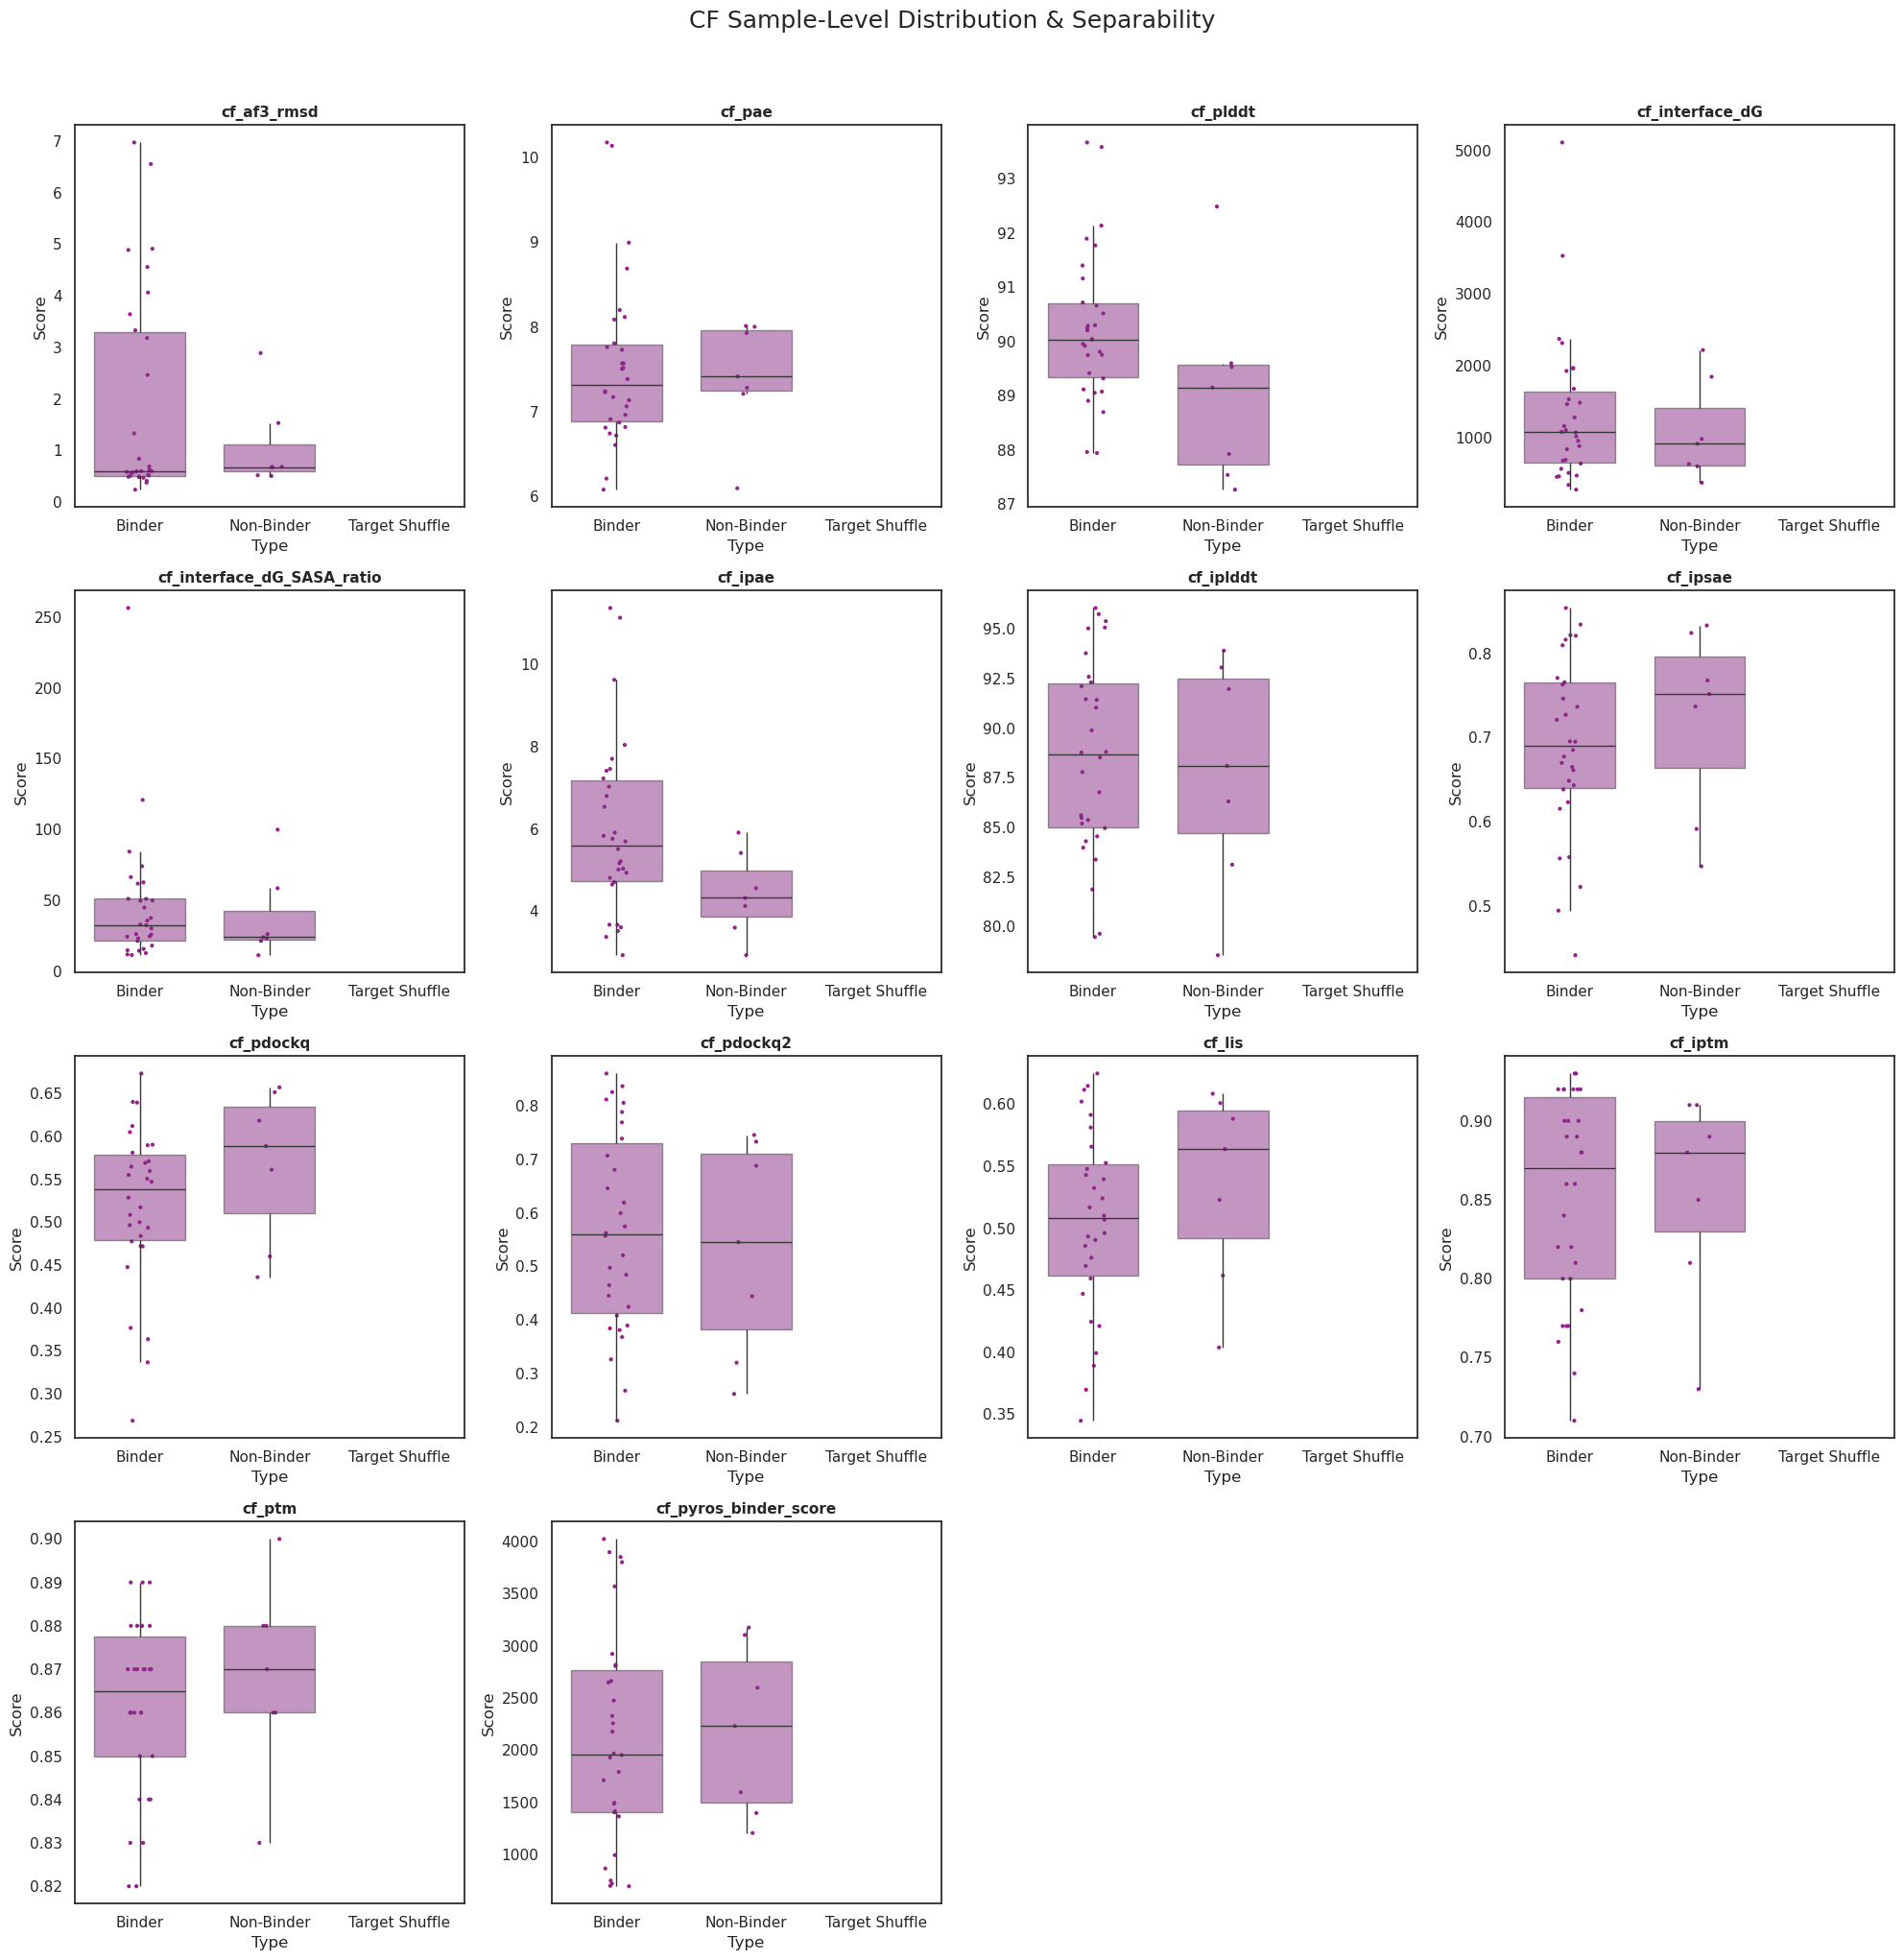

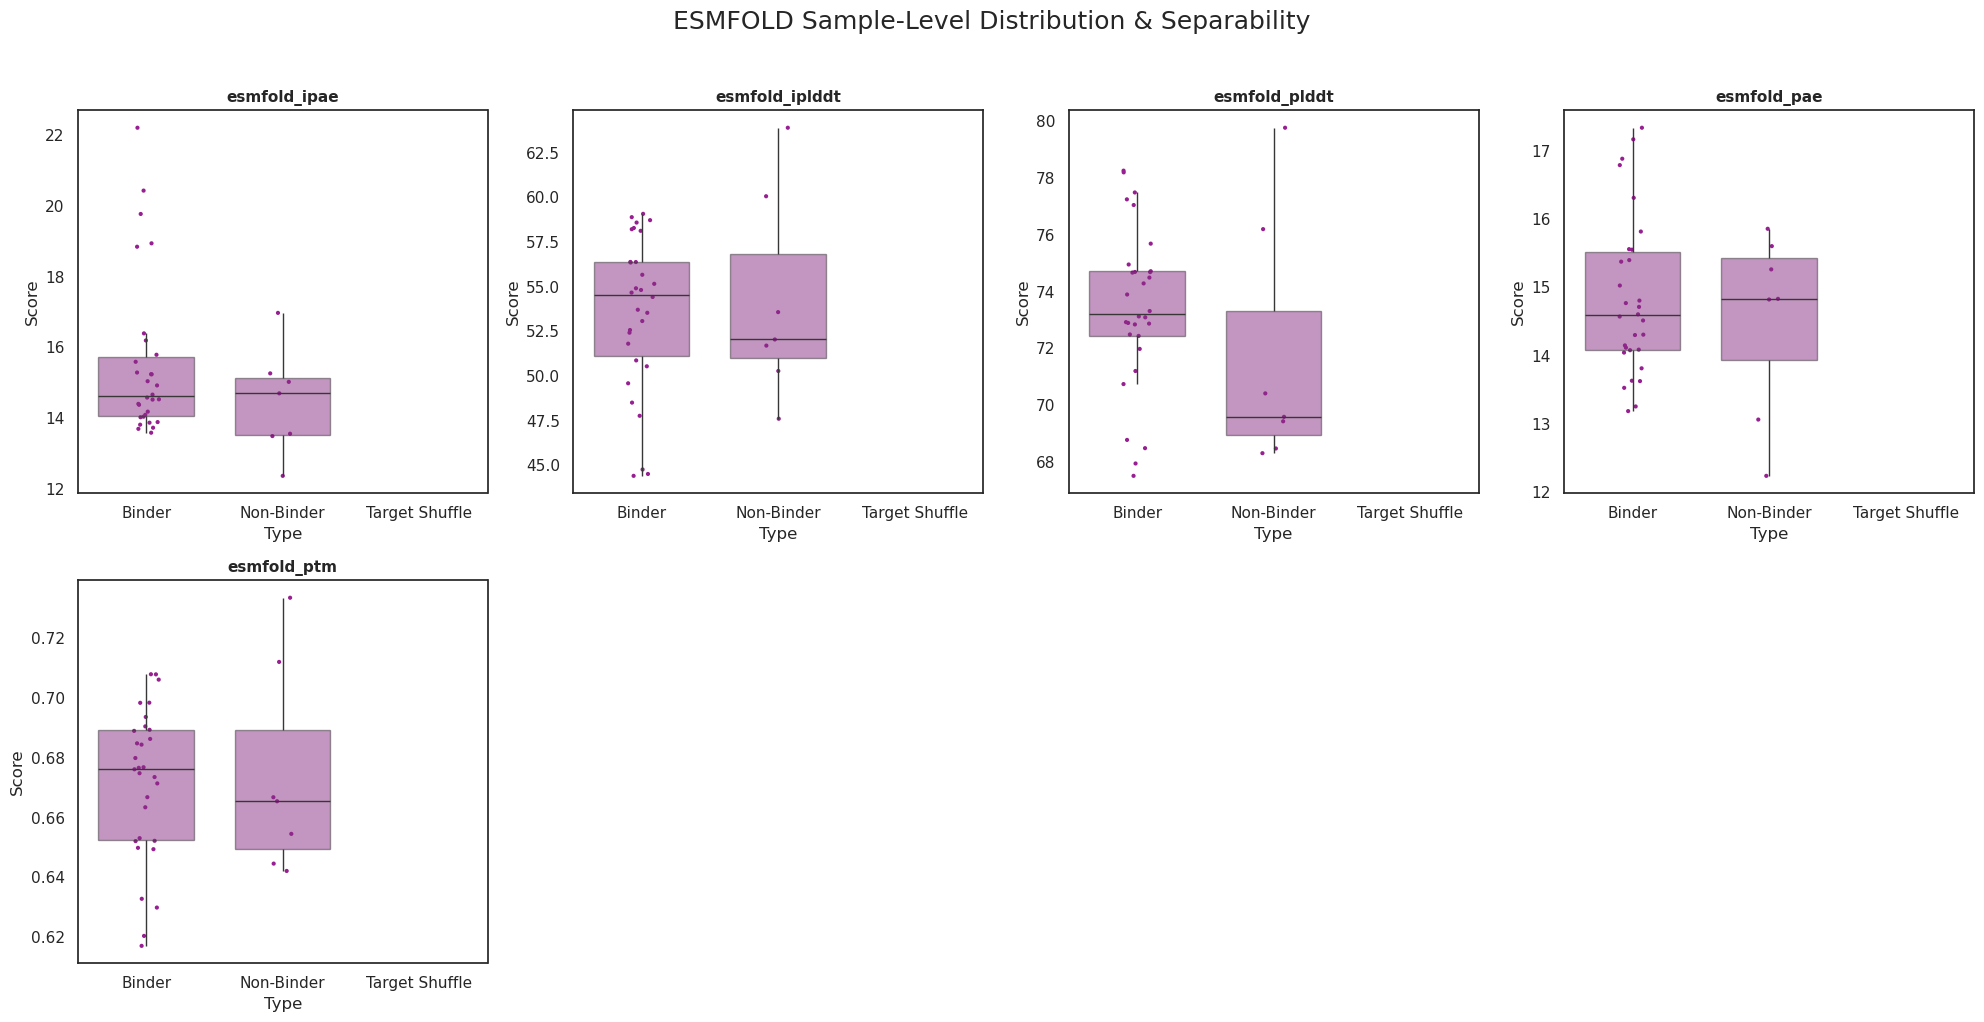

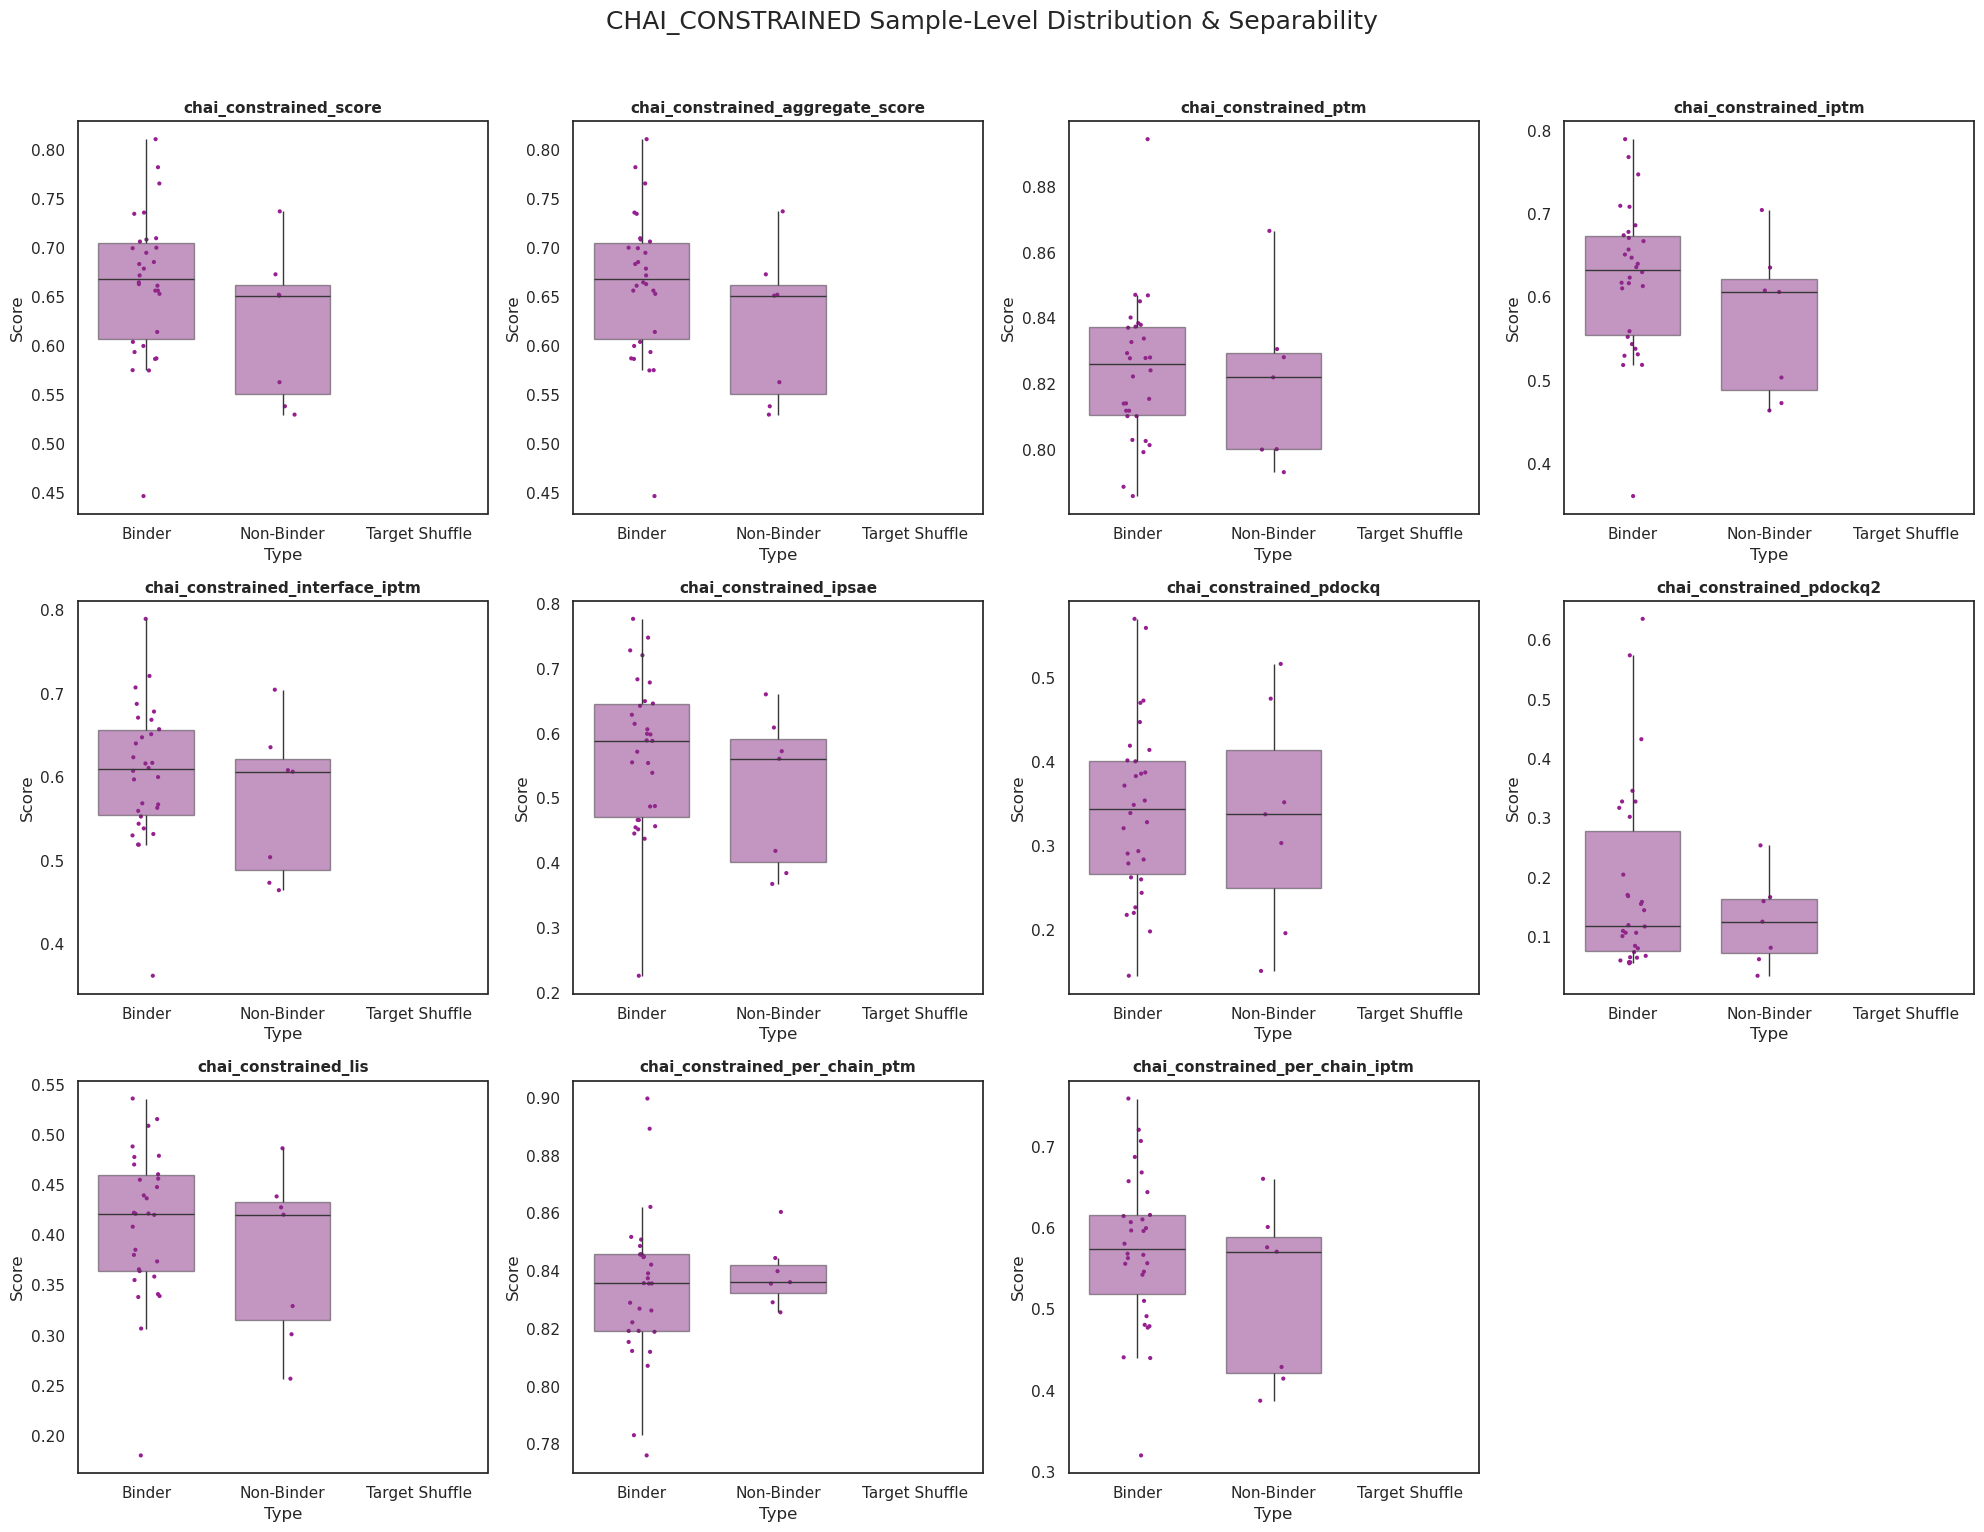

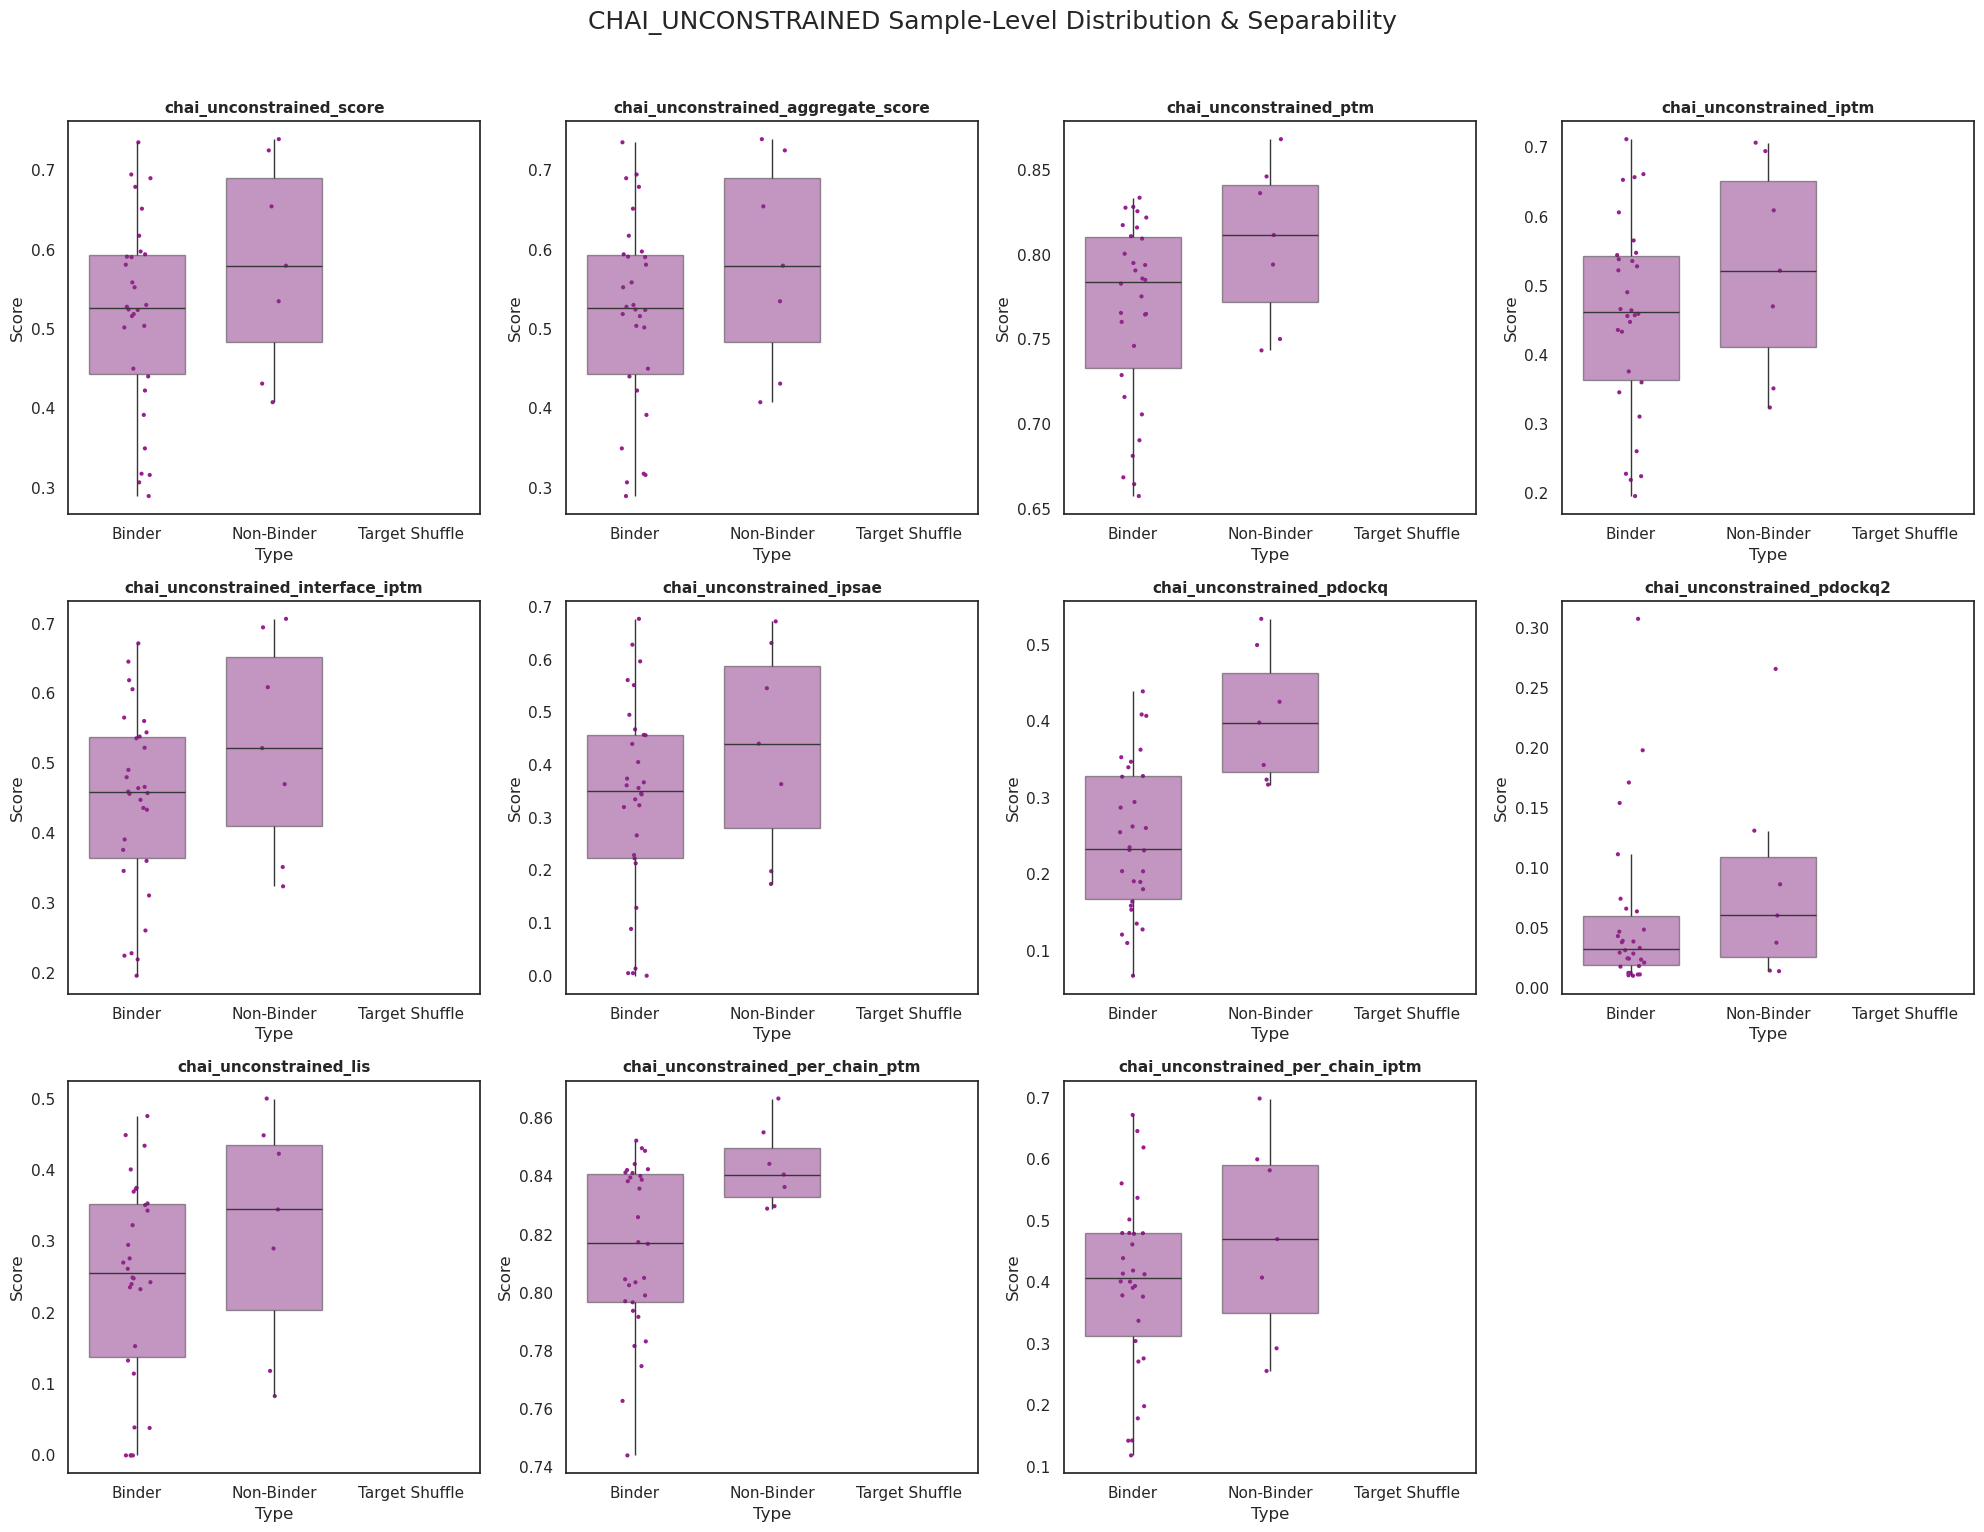

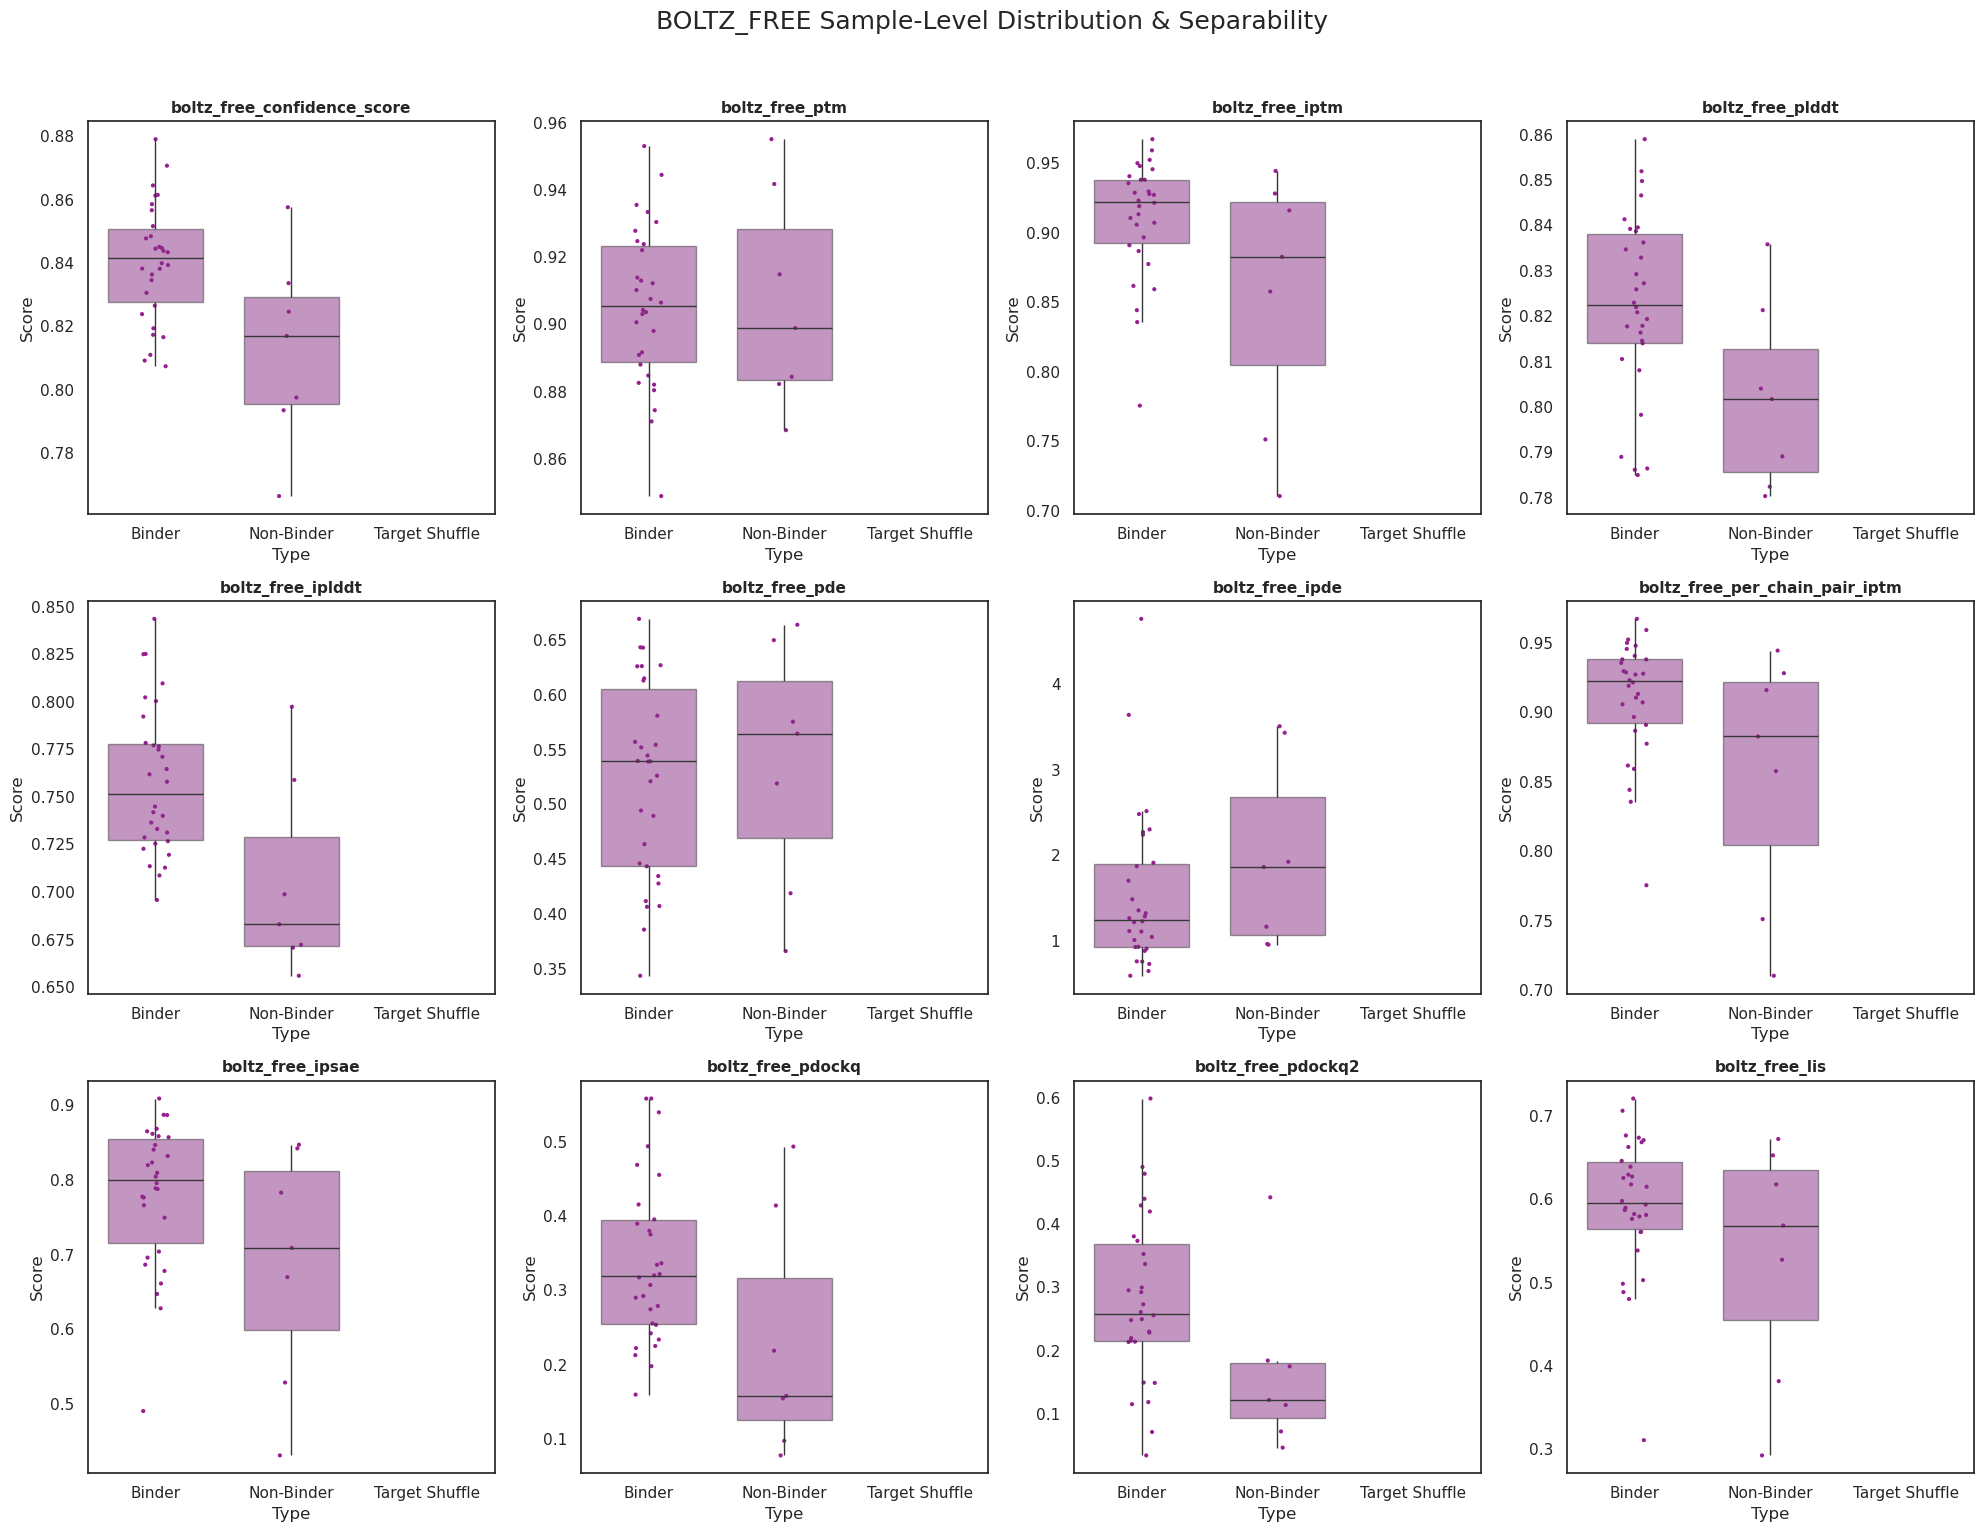

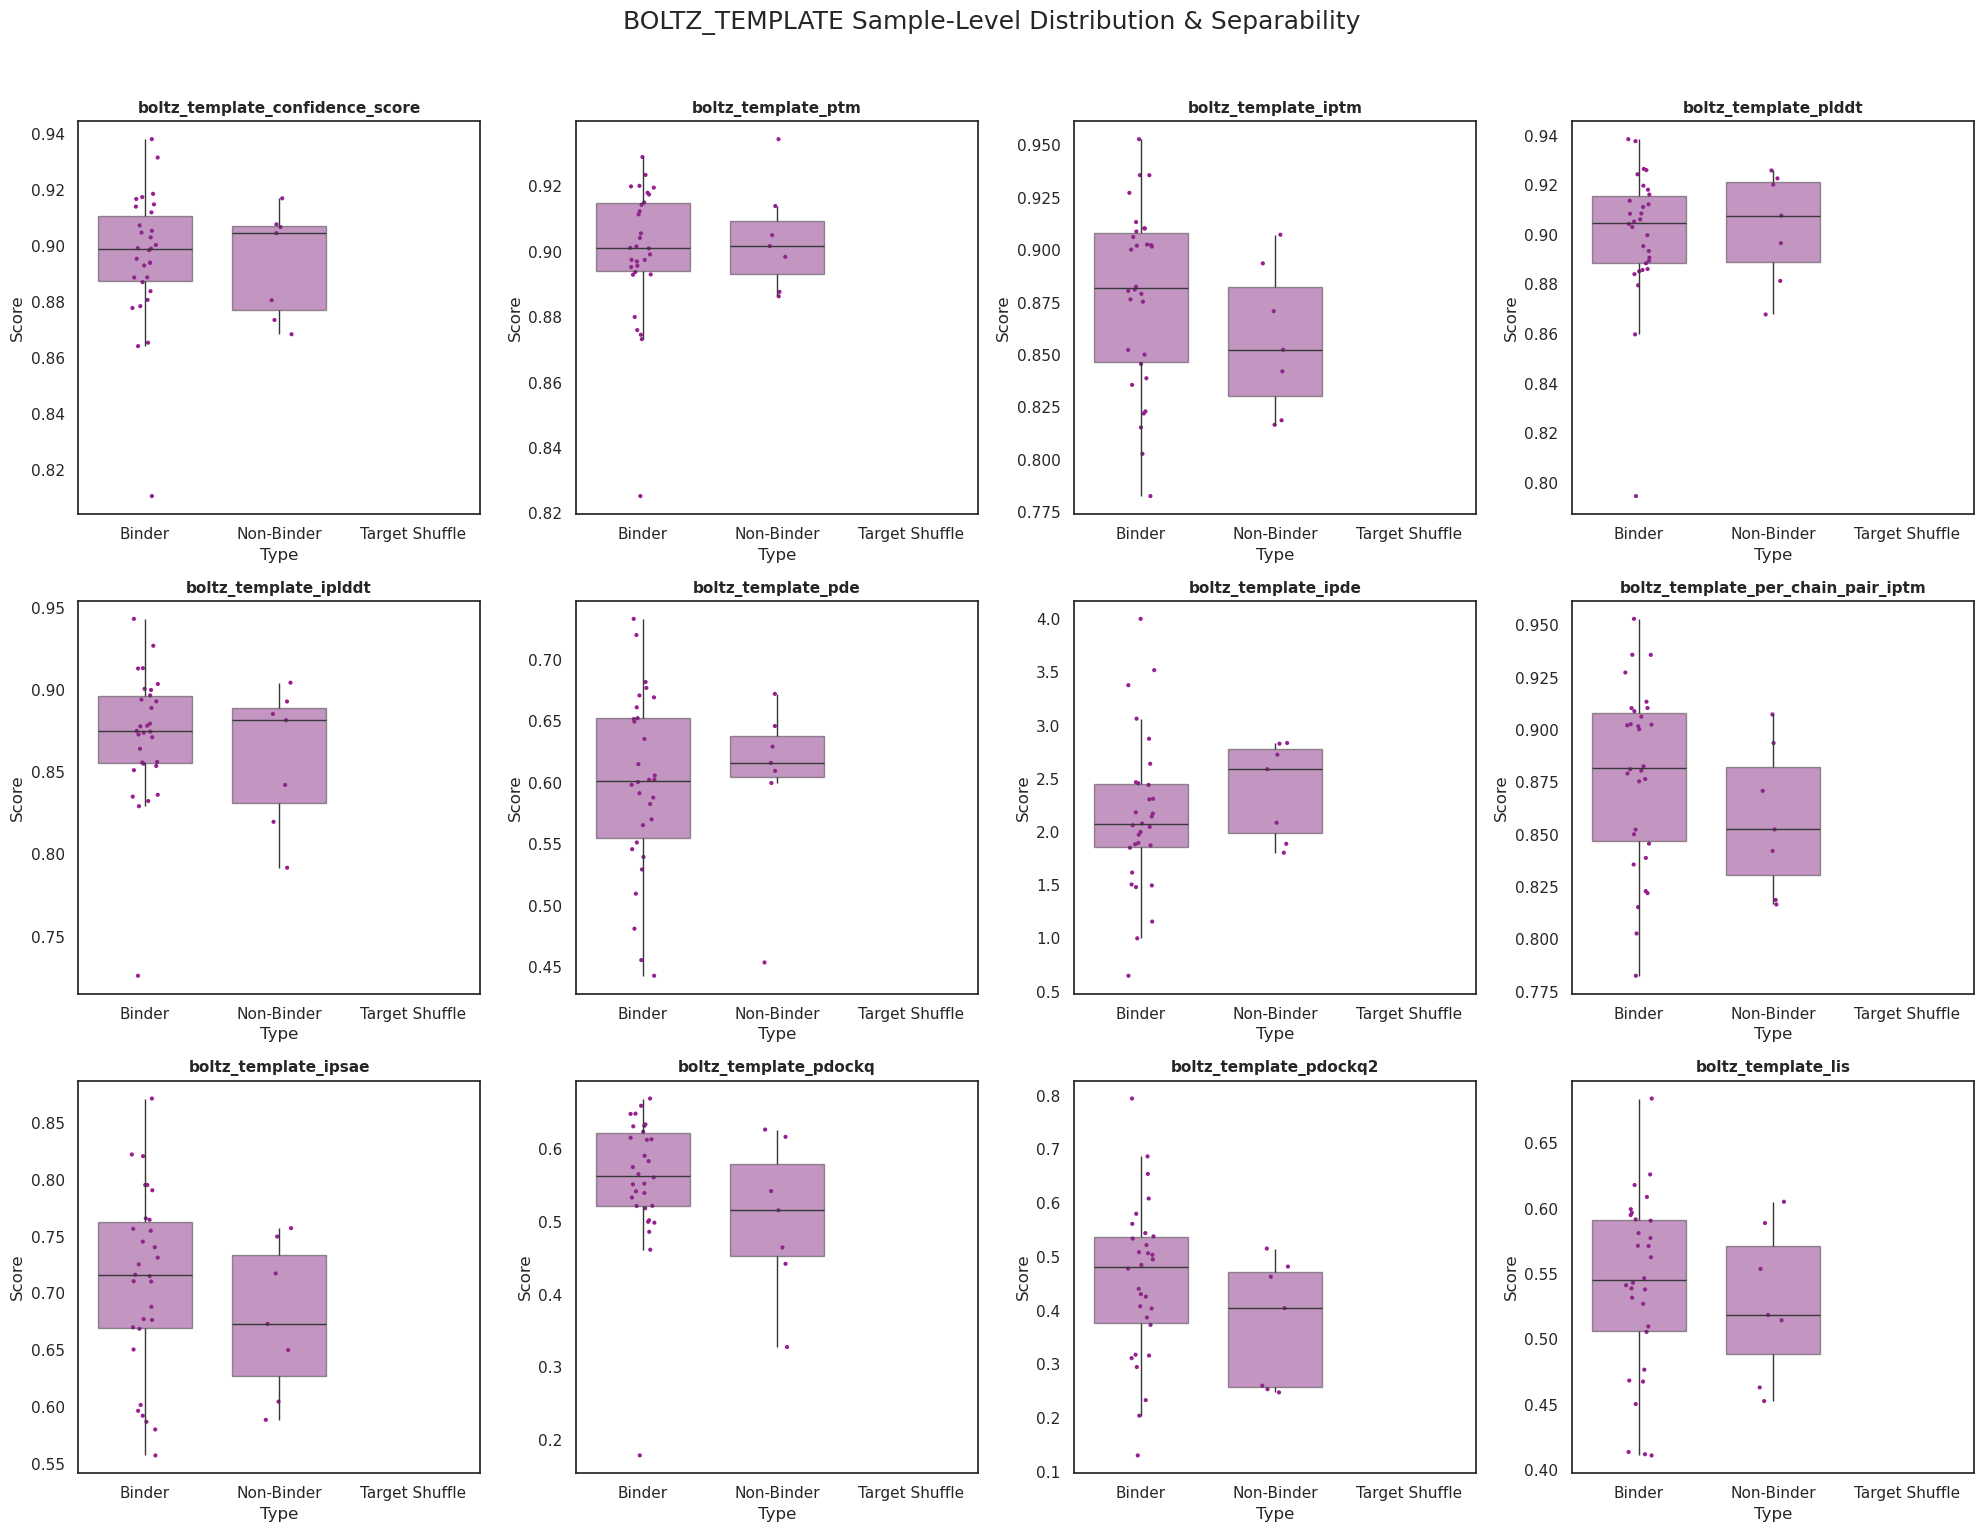

Finished generating scatterplots for BOLTZ_TEMPLATE group.


In [19]:
# Detailed Separability

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if there are multiple classes to compare
has_both_classes = scores_df['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if scores_df[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue


    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # df contains 'binder_type'
        plot_df = scores_df.dropna(subset=[col]).copy()

        
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())
        #x_order = sorted(plot_df['binder'].unique())
        x_order = [
            "Binder",
            "Non-Binder",
            "Target Shuffle"
        ]

        # Stripplot
        sns.stripplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            hue='source',
            hue_order=hue_order,
            dodge=True,
            jitter=0.1, 
            palette=colors_map,
            size=3,
            ax=ax,
            legend=False 
        )
        
        # Boxplot  ???
        sns.boxplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            dodge=True,
            showcaps=False, 
            fill=True, 
            hue='source',
            hue_order=hue_order,
            palette=colors_map,
            ax=ax,
            width=0.7,
            zorder=10, 
            showfliers=False,
            legend=False 
        )

        for artist in ax.patches:
            artist.set_alpha(0.5)
        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Type')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")

#### Correlation Matrix

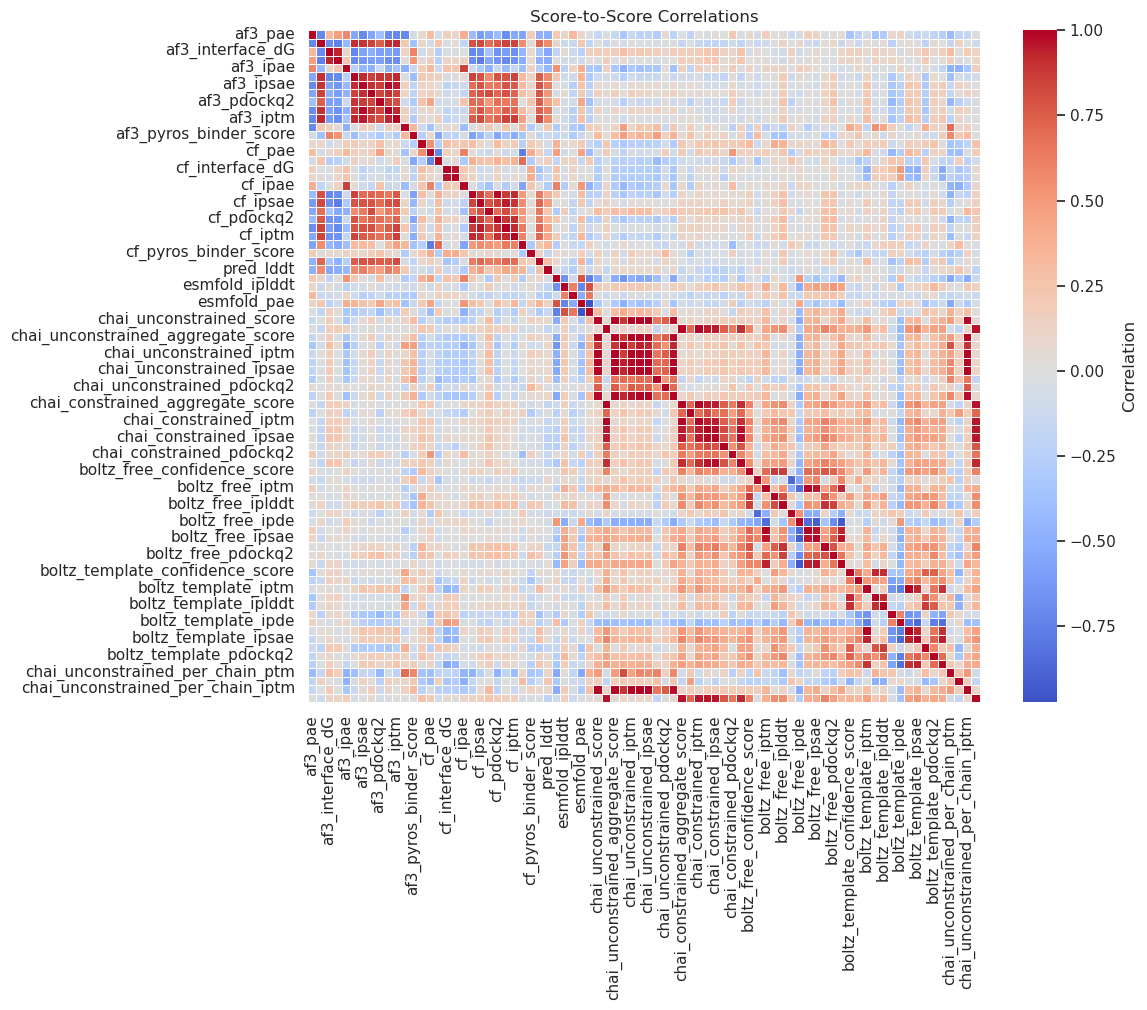

<Figure size 640x480 with 0 Axes>

In [21]:
# directions!!!!!
# Create numeric df and drop binder column
numeric_df = scores_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('iteration', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=500, bbox_inches='tight')
